In [1]:
import numpy as np
from mpes import visualization as vis
import fuller
import matplotlib.pyplot as plt
import os

2025-10-15 18:58:55.623310: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-15 18:58:55.623811: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-15 18:58:55.686382: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-15 18:59:01.013053: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
data_path = '../' # Put in Path to a storage of at least 20 Gbyte free space.
if not os.path.exists(data_path + "/data.zip"):
    os.system(f"curl -L --output {data_path}/data.zip https://zenodo.org/records/7314278/files/data.zip")
if not os.path.isdir(data_path + "/data"):
    os.system(f"unzip -d {data_path} -o {data_path}/data")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1318M  100 1318M    0     0   760k      0  0:29:34  0:29:34 --:--:-- 1005k


Archive:  ..//data.zip
   creating: ../data/
   creating: ../data/pes/
  inflating: ../data/pes/3_smooth.h5  
  inflating: ../data/pes/1_sym.h5    
  inflating: ../data/pes/0_binned.h5  
  inflating: ../data/pes/2_mclahe.h5  
   creating: ../data/theory/
  inflating: ../data/theory/WSe2_PBEsol_bands.mat  
   creating: ../data/theory/bands_1BZ/
  inflating: ../data/theory/bands_1BZ/wse2_pbesol_bandcuts.h5  
  inflating: ../data/theory/bands_1BZ/wse2_hse_bandcuts.h5  
  inflating: ../data/theory/bands_1BZ/wse2_pbe_bandcuts.h5  
  inflating: ../data/theory/bands_1BZ/wse2_lda_bandcuts.h5  
   creating: ../data/theory/bands_padded/
  inflating: ../data/theory/bands_padded/wse2_pbe_bands_padded.h5  
  inflating: ../data/theory/bands_padded/wse2_pbesol_bands_padded.h5  
  inflating: ../data/theory/bands_padded/wse2_hse_bands_padded.h5  
  inflating: ../data/theory/WSe2_LDA_bands.mat  
   creating: ../data/theory/hslines/
  inflating: ../data/theory/hslines/WSe2_bandlines_PBE_186.mat  
  infla

In [3]:
pbedata = fuller.utils.load_calculation('../data/theory/patch/band_all_paths_cart.out.pbe')

In [4]:
pbedata.shape

(55, 120, 366)

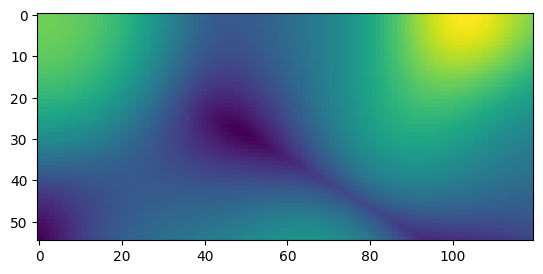

In [5]:
plt.imshow(pbedata[..., 285])

In [6]:
pbe_vb, pbe_cb = fuller.generator.bandstack(pbedata[:50,:,:], nvb=80, ncb=40, gap_id=286, cvd=103.9)

100%|██████████| 40/40 [00:01<00:00, 27.43it/s]


In [7]:
pbe_vb.shape, pbe_cb.shape

((80, 319, 339), (40, 319, 339))

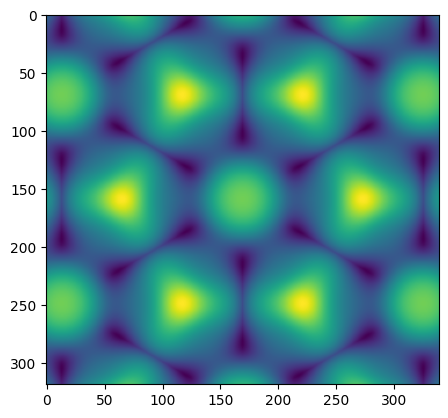

In [8]:
plt.imshow(pbe_vb[0,...])

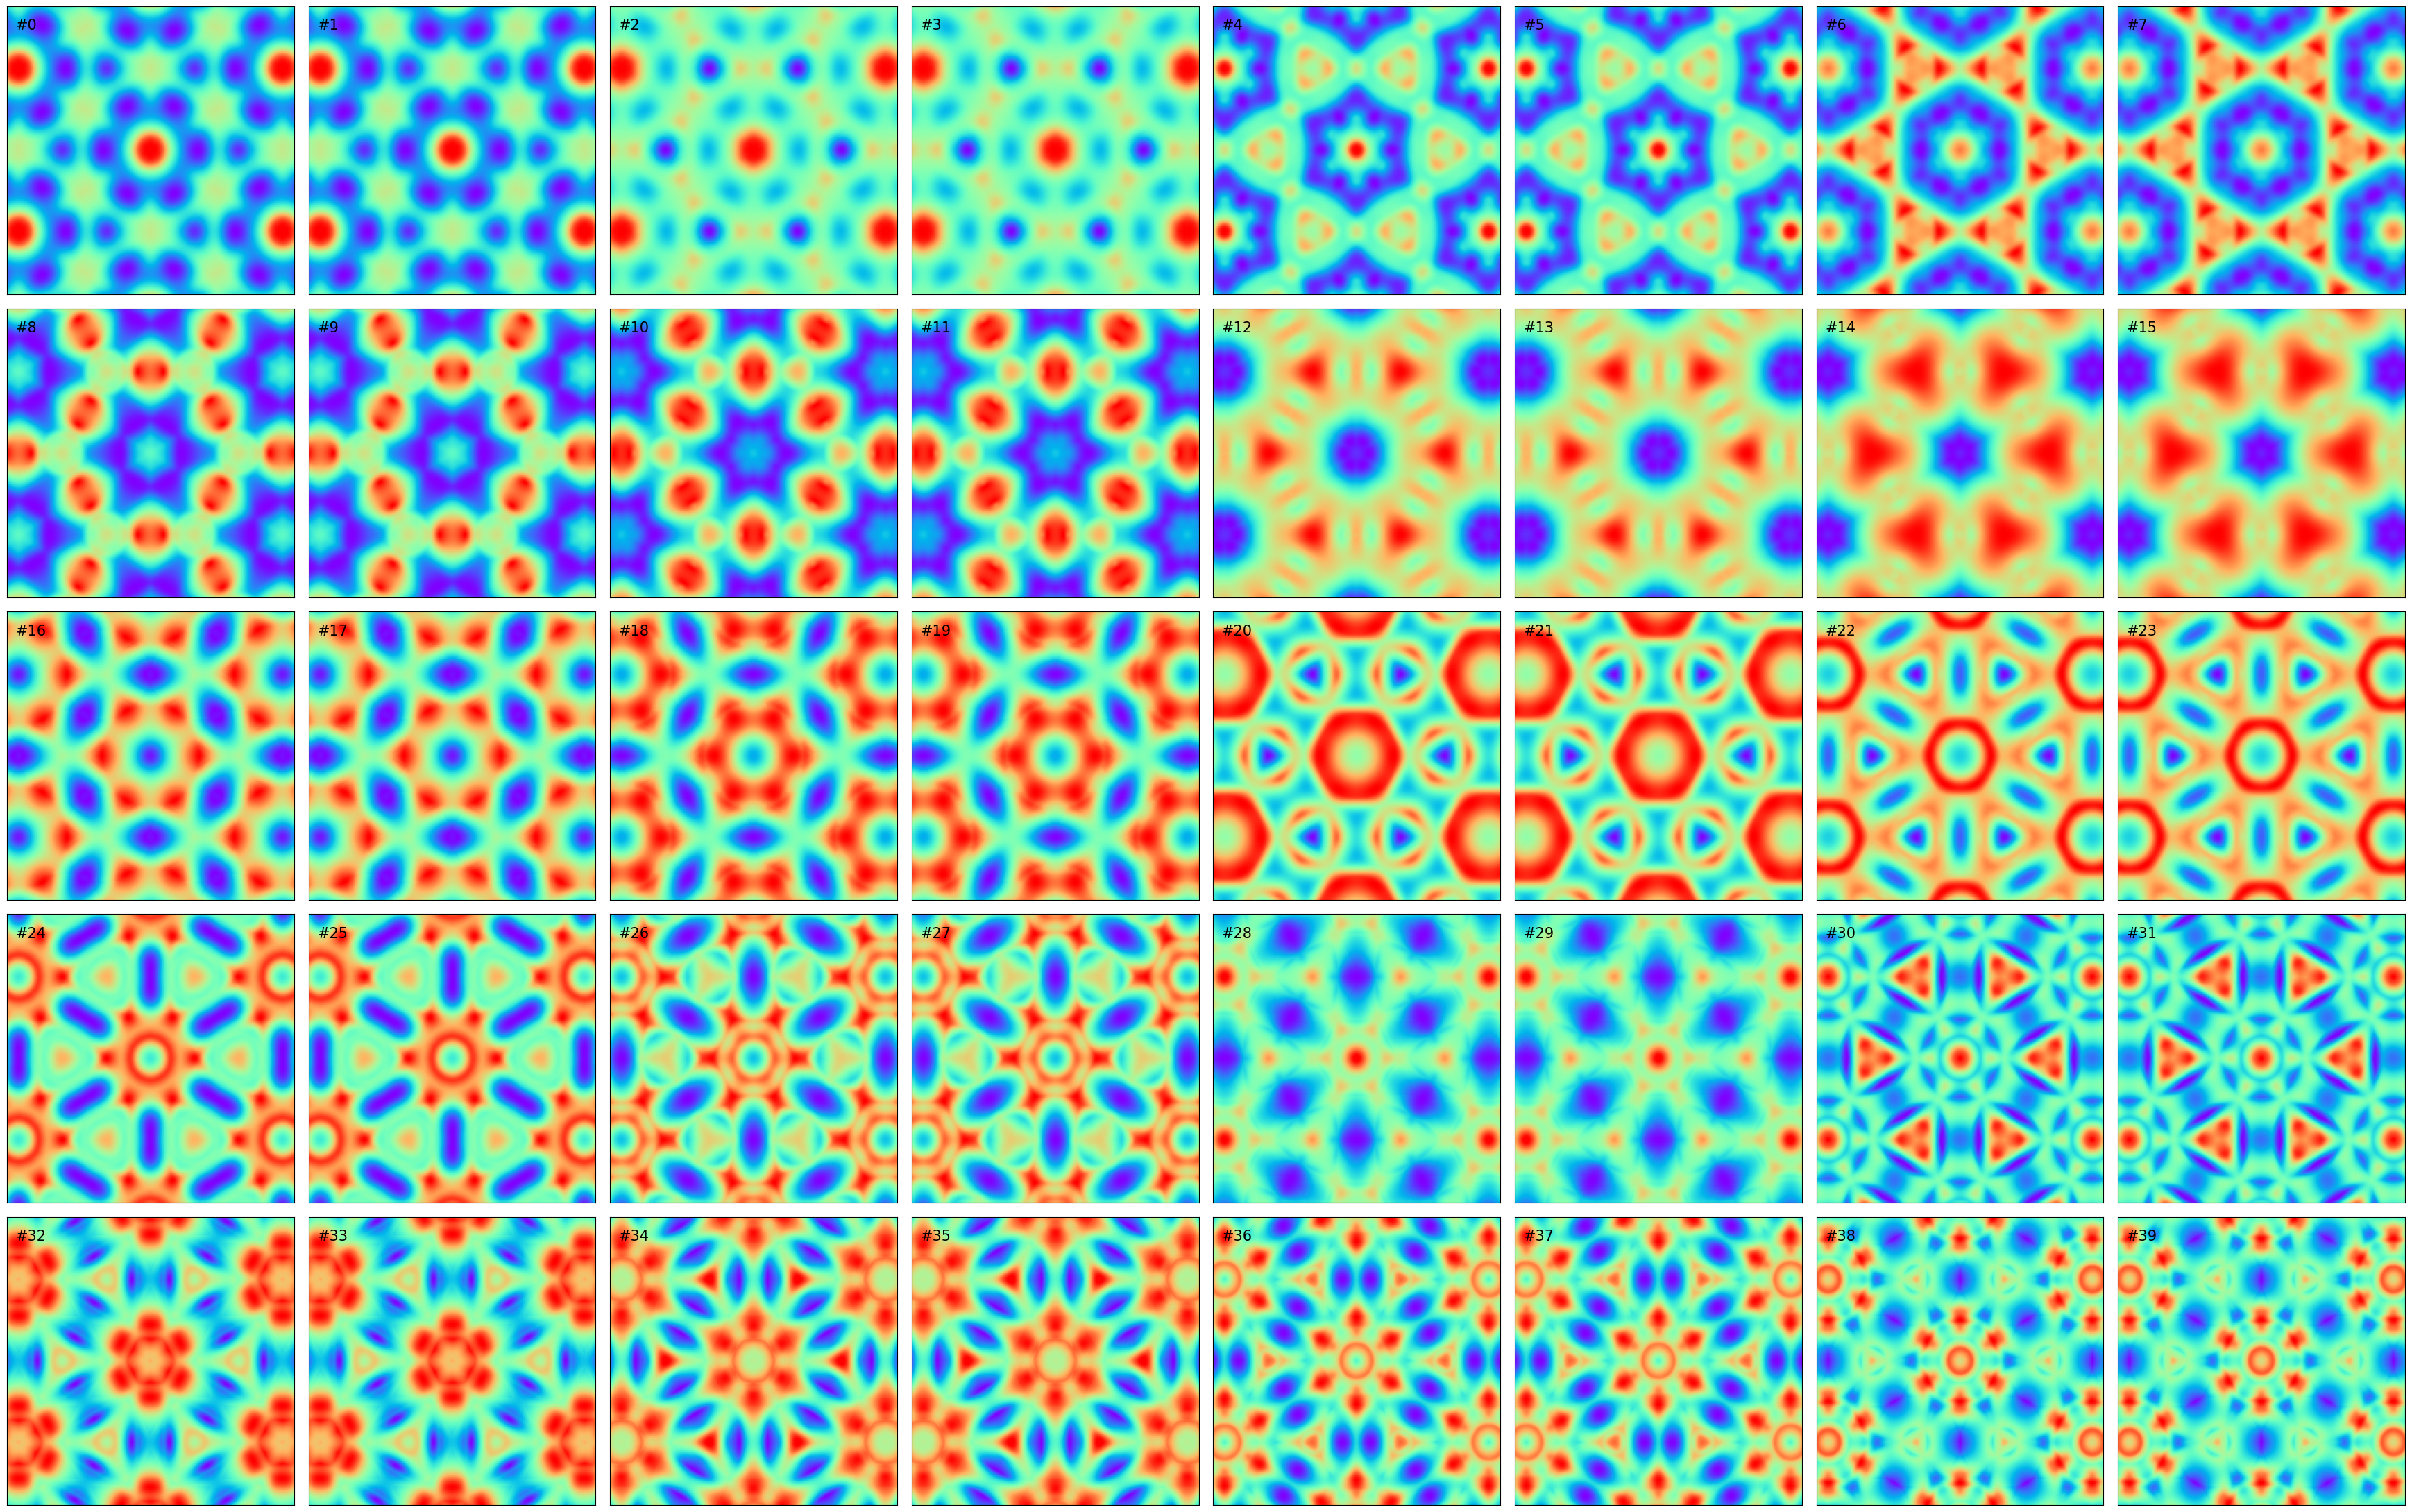

In [9]:
axs = vis.sliceview3d(pbe_cb, axis=0, ncol=8, colormap='rainbow');